# Speech Emotion Recognition (SER) Model Training
This notebook trains a Deep Learning model (CNN + LSTM) to classify emotions from human speech using the RAVDESS dataset.

## 1. Imports and Setup
Run this cell to import the necessary libraries.

In [9]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization
from keras.utils import to_categorical
import pickle

# Define emotions based on RAVDESS filename conventions
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Data Loading and Preprocessing
We use `librosa` to load `.wav` files, normalize, and extract MFCCs + Mel-Spectrograms.

In [10]:
def extract_features(file_path):
    # Load audio file (3s duration, offset by 0.5s to skip silence)
    y, sr = librosa.load(file_path, duration=3.0, offset=0.5, sr=22050)
    
    # 1. MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    
    # 2. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_mean = np.mean(mel.T, axis=0)
    
    # Concatenate features
    features = np.hstack((mfcc_mean, mel_mean))
    return features

# Path to your dataset (Assuming RAVDESS Audio_Speech_Actors_01-24 dataset)
data_path = '../dataset/RAVDESS/'
X, y_labels = [], []

if os.path.exists(data_path):
    print(f"Found dataset at {data_path}. Extracting features...")
    for actor_dir in os.listdir(data_path):
        actor_path = os.path.join(data_path, actor_dir)
        if os.path.isdir(actor_path):
            for file in os.listdir(actor_path):
                if file.endswith('.wav'):
                    file_path = os.path.join(actor_path, file)
                    
                    # Extract emotion from RAVDESS filename (e.g., 03-01-01-01-01-01-01.wav)
                    emotion_code = file.split('-')[2]
                    emotion = emotion_map.get(emotion_code, 'unknown')
                    
                    features = extract_features(file_path)
                    X.append(features)
                    y_labels.append(emotion)
    print(f"Successfully extracted {len(X)} samples.")
else:
    print(f"Warning: Dataset path {data_path} not found. Please place RAVDESS dataset there.")

X = np.array(X)
y_labels = np.array(y_labels)

Found dataset at ../dataset/RAVDESS/. Extracting features...


C:\Users\Hustle\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Successfully extracted 1440 samples.


## 3. Label Encoding and Train-Test Split
Convert categorical emotion string labels to one-hot vectors and split the dataset.

In [11]:
# Encode string labels into integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)

# Reshape X to fit the Conv1D + LSTM input requirements (samples, timesteps, features)
X_reshaped = np.expand_dims(X, axis=2)

X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_categorical, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (1152, 168, 1)
X_test shape: (288, 168, 1)
y_train shape: (1152, 8)


## 4. CNN + LSTM Model Architecture
We use a CNN to extract local spatial patterns from the acoustic features, and an LSTM to capture temporal dynamics.

In [12]:
model = Sequential()

# CNN Layer 1
model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.3))

# CNN Layer 2
model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.3))

# LSTM Layer
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.3))

# Dense Output Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\Hustle\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 168, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 168, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 84, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 84, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 84, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 84, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,400 (1.17 MB)

 Trainable params: 306,632 (1.17 MB)

 Non-trainable params: 768 (3.00 KB)

## 5. Model Training and Evaluation

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.1398 - loss: 2.0852 - val_accuracy: 0.1354 - val_loss: 2.0698
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1380 - loss: 2.0792 - val_accuracy: 0.1806 - val_loss: 2.0648
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1510 - loss: 2.0587 - val_accuracy: 0.1458 - val_loss: 2.0650
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1901 - loss: 1.9634 - val_accuracy: 0.1389 - val_loss: 2.4305
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2257 - loss: 1.9271 - val_accuracy: 0.1458 - val_loss: 3.7313
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.2448 - loss: 1.8621 - val_accuracy: 0.1458 - val_loss: 4.5663
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2769 - loss: 1.8239 - val_accuracy: 0.1458 - val_loss: 5.3520
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2535 - loss: 1.8331 - val_accuracy: 0.1458 - v

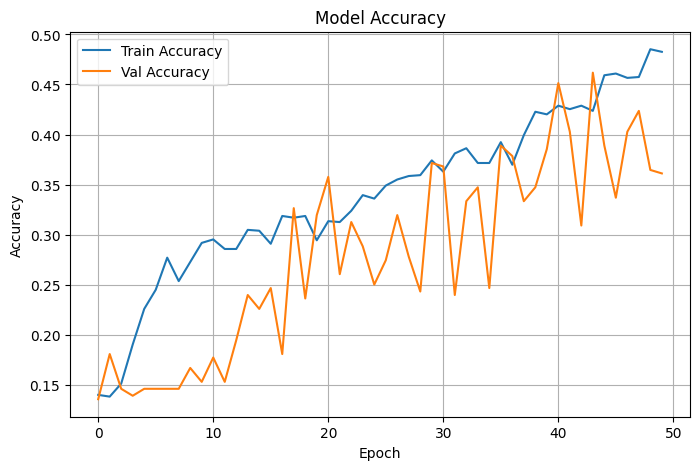

In [13]:
# Train the model
history = model.fit(X_train, y_train, batch_size=32, epochs=50, validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# Plot the accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

## 6. Save the Model and Label Encoder
Save the compiled model and label encoder to disk so our FastAPI backend can load them later.

In [14]:
# Ensure the saved_models directory exists
os.makedirs('../saved_models', exist_ok=True)

# Save model architecture and weights
model.save('../saved_models/ser_model.h5')

# Save the Label Encoder for decoding predictions in the backend
with open('../saved_models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model and Label Encoder successfully saved to '../saved_models/'")

Model and Label Encoder successfully saved to '../saved_models/'
